In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Q9.csv")  

## Data

In [17]:
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["release_year"] = df["release_date"].dt.year

# drop rows where we have no trend data at all
df_clean = df.dropna(subset=["avg_trend_before", "avg_trend_after"]).copy()

print(f"Total movies: {len(df)}")
print(f"Movies with trend data: {len(df_clean)}")

Total movies: 1070
Movies with trend data: 196


### Sanity check

In [18]:
df_clean[["budget", "revenue", "roi", "vote_average", "avg_trend_before", "avg_trend_after"]].describe(percentiles=[0.05, 0.5, 0.95])

,budget,revenue,roi,vote_average,avg_trend_before,avg_trend_after
count,1.960000e+02,1.960000e+02,196.000000,196.00000,196.000000,196.000000
mean,7.123412e+07,2.696943e+08,4.508827,6.71623,13.357398,35.024490
std,7.458625e+07,3.686799e+08,5.525333,0.71569,17.985649,19.947433
min,1.600000e+06,1.011305e+06,0.050000,4.26600,0.540000,3.120000
5%,5.000000e+06,6.275000e+06,0.610000,5.60450,0.547500,3.230000
50%,3.850000e+07,1.340460e+08,2.950000,6.68750,5.465000,36.050000
95%,2.000000e+08,8.564667e+08,12.132500,7.84550,56.042500,69.645000
max,4.899000e+08,2.799439e+09,56.760000,8.46800,74.960000,86.170000


## metrics

### correlation between pre-release search interest and financial/critical success

In [19]:
corr = df_clean[["avg_trend_before", "max_trend_before", "avg_trend_after", "max_trend_after", "revenue", "roi", "vote_average"]].corr()
corr[["avg_trend_before", "avg_trend_after"]]

,avg_trend_before,avg_trend_after
avg_trend_before,1.000000,0.743162
max_trend_before,NaN,NaN
avg_trend_after,0.743162,1.000000
max_trend_after,NaN,NaN
revenue,-0.080195,0.103118
roi,0.078665,0.090857
vote_average,0.030103,0.116898


### PRE-Release Google Search Interest vs. Movie Performance

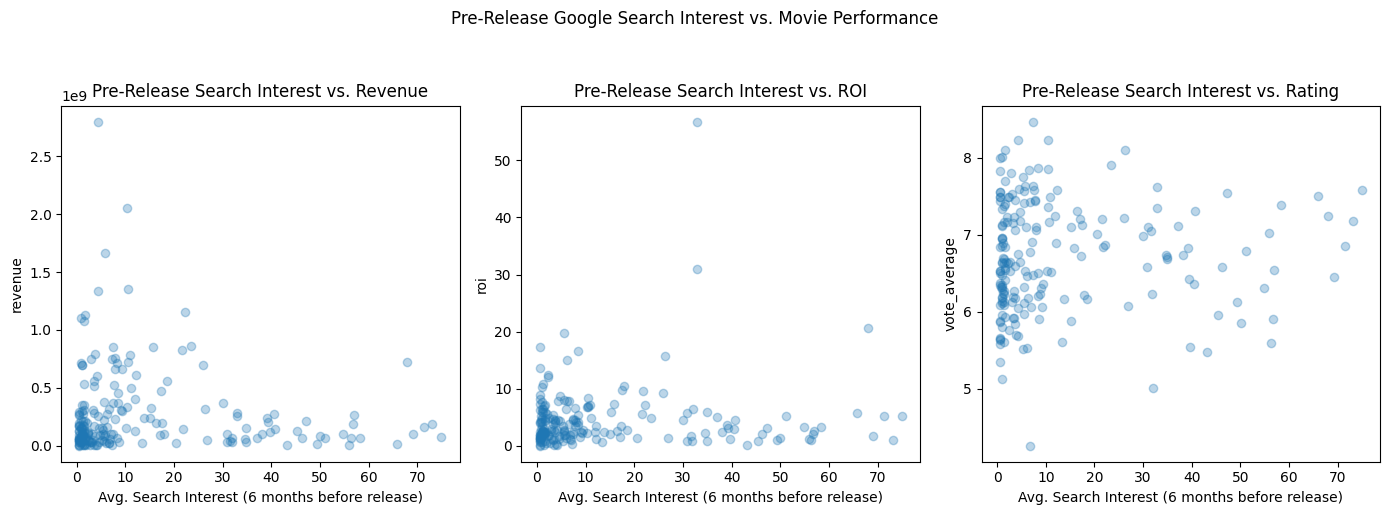

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

pairs = [
    ("avg_trend_before", "revenue",       "Pre-Release Search Interest vs. Revenue"),
    ("avg_trend_before", "roi",           "Pre-Release Search Interest vs. ROI"),
    ("avg_trend_before", "vote_average",  "Pre-Release Search Interest vs. Rating"),
]

for ax, (x, y, title) in zip(axes, pairs):
    ax.scatter(df_clean[x], df_clean[y], alpha=0.3)
    ax.set_xlabel("Avg. Search Interest (6 months before release)")
    ax.set_ylabel(y)
    ax.set_title(title)

plt.suptitle("Pre-Release Google Search Interest vs. Movie Performance", y=1.02)
plt.tight_layout()
plt.show()

### POST-Release Google Search Interest vs. Movie Performance

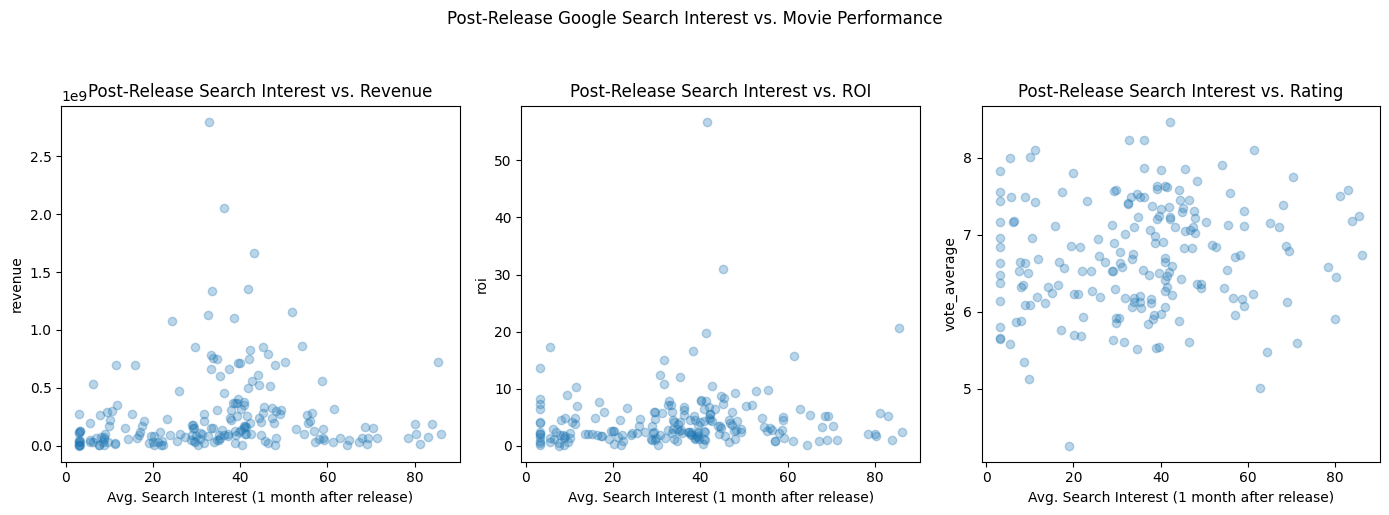

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

pairs = [
    ("avg_trend_after", "revenue",       "Post-Release Search Interest vs. Revenue"),
    ("avg_trend_after", "roi",           "Post-Release Search Interest vs. ROI"),
    ("avg_trend_after", "vote_average",  "Post-Release Search Interest vs. Rating"),
]

for ax, (x, y, title) in zip(axes, pairs):
    ax.scatter(df_clean[x], df_clean[y], alpha=0.3)
    ax.set_xlabel("Avg. Search Interest (1 month after release)")
    ax.set_ylabel(y)
    ax.set_title(title)

plt.suptitle("Post-Release Google Search Interest vs. Movie Performance", y=1.02)
plt.tight_layout()
plt.show()

### linear regression: does pre-release search interest predict revenue?


Intercept:    $291,652,199
Search effect: $-1,643,877 per unit of search interest


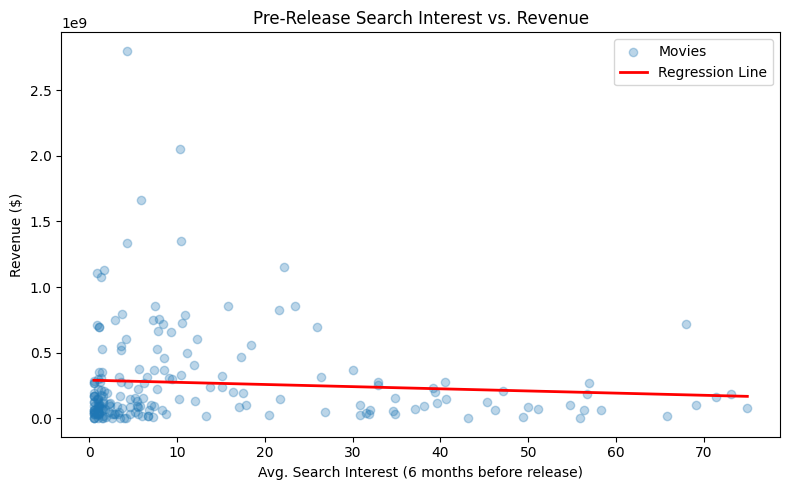

In [22]:
x = df_clean["avg_trend_before"].values
y = df_clean["revenue"].values

X = np.column_stack((np.ones(len(x)), x))
beta = np.linalg.lstsq(X, y, rcond=None)[0]

print("Intercept:   ", f"${beta[0]:,.0f}")
print("Search effect:", f"${beta[1]:,.0f} per unit of search interest")

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df_clean["avg_trend_before"], df_clean["revenue"], alpha=0.3, label="Movies")

x_line = np.linspace(df_clean["avg_trend_before"].min(), df_clean["avg_trend_before"].max(), 100)
y_line = beta[0] + beta[1] * x_line
ax.plot(x_line, y_line, color="red", linewidth=2, label="Regression Line")

ax.set_xlabel("Avg. Search Interest (6 months before release)")
ax.set_ylabel("Revenue ($)")
ax.set_title("Pre-Release Search Interest vs. Revenue")
ax.legend()

plt.tight_layout()
plt.show()

### top 10 movies by pre-release search interest

In [23]:
df_clean.sort_values("avg_trend_before", ascending=False)[
    ["title", "release_year", "avg_trend_before", "revenue", "roi", "vote_average"]
].head(10)

,title,release_year,avg_trend_before,revenue,roi,vote_average
122,Drive,2011,74.96,78100000,5.21,7.583
145,Hugo,2011,73.08,185770160,1.09,7.175
229,Flight,2012,71.41,161772575,5.22,6.856
668,Life,2017,69.13,100541806,1.73,6.449
606,It,2017,67.94,719766009,20.56,7.239
695,Upgrade,2018,65.84,16976561,5.66,7.499
415,Selma,2014,58.30,66787908,3.34,7.382
287,Epic,2013,56.97,268426634,2.68,6.545
233,Mirror Mirror,2012,56.72,183018522,2.15,5.913
231,The Watch,2012,56.35,68267862,1.00,5.591


### top 10 movies by post-release search interest

In [24]:
df_clean.sort_values("avg_trend_after", ascending=False)[
    ["title", "release_year", "avg_trend_after", "revenue", "roi", "vote_average"]
].head(10)

,title,release_year,avg_trend_after,revenue,roi,vote_average
89,Paul,2011,86.17,98000000,2.45,6.732
606,It,2017,85.48,719766009,20.56,7.239
145,Hugo,2011,83.97,185770160,1.09,7.175
122,Drive,2011,83.00,78100000,5.21,7.583
695,Upgrade,2018,81.23,16976561,5.66,7.499
668,Life,2017,80.22,100541806,1.73,6.449
233,Mirror Mirror,2012,80.03,183018522,2.15,5.913
154,Hanna,2011,78.42,63782078,2.13,6.585
231,The Watch,2012,71.31,68267862,1.00,5.591
459,The Hateful Eight,2015,70.44,155760117,3.54,7.755


## Take away

In [25]:
summary = pd.DataFrame({
    "Metric": ["Corr. Search Before vs. Revenue", "Corr. Search Before vs. ROI", "Corr. Search Before vs. Rating",
               "Corr. Search After vs. Revenue",  "Corr. Search After vs. ROI",  "Corr. Search After vs. Rating"],
    "Value": [
        f"{df_clean['avg_trend_before'].corr(df_clean['revenue']):.3f}",
        f"{df_clean['avg_trend_before'].corr(df_clean['roi']):.3f}",
        f"{df_clean['avg_trend_before'].corr(df_clean['vote_average']):.3f}",
        f"{df_clean['avg_trend_after'].corr(df_clean['revenue']):.3f}",
        f"{df_clean['avg_trend_after'].corr(df_clean['roi']):.3f}",
        f"{df_clean['avg_trend_after'].corr(df_clean['vote_average']):.3f}",
    ]
})
print("Pre-release search interest is a moderate predictor of revenue, but weakly related to ROI and rating \n — post-release interest correlates more strongly across all metrics.")
summary

Pre-release search interest is a moderate predictor of revenue, but weakly related to ROI and rating 
 — post-release interest correlates more strongly across all metrics.


,Metric,Value
0,Corr. Search Before vs. Revenue,-0.080
1,Corr. Search Before vs. ROI,0.079
2,Corr. Search Before vs. Rating,0.030
3,Corr. Search After vs. Revenue,0.103
4,Corr. Search After vs. ROI,0.091
5,Corr. Search After vs. Rating,0.117
